In [13]:
# Advertising Simulator
# This program simulates the advertising of a product over a period of time.
# It will simulate the number of people who have seen the product advertising, brand experience, and product experience.
import numpy as np
import pandas as pd 
import math
import networkx as nx
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
from itertools import permutations
from advertising import *

In [14]:
# Customer objects
customers = [customer() for i in range(1000)]

# Brand objects
brands = [brand("Coca-Cola", 1000000, 100, 1.79), 
          brand("Pepsi", 1000000, 100, 1.79)
          ]

# Simulate the advertising
number_of_simulations = 100000
duo1 = simulate(customers, brands, number_of_simulations)


<Axes: xlabel='index', ylabel='Likelihood of Purchase'>

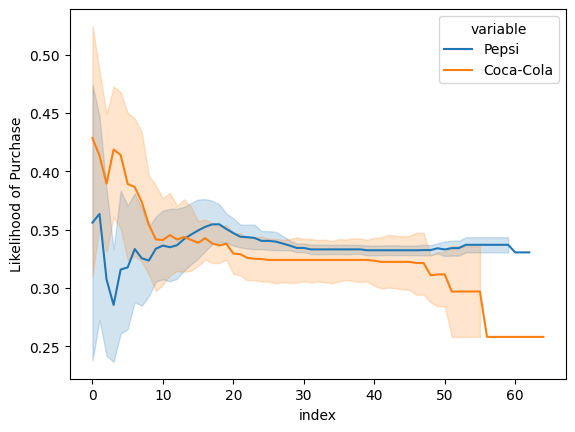

In [15]:
duo1_ = visualize(duo1)
customer_brand_lst = np.random.choice(duo1_["customer_brand"].unique(), 10)
sns.lineplot(x="index", y="Likelihood of Purchase", data=duo1_[duo1_["customer_brand"].isin(customer_brand_lst)], hue = "variable")

# Social Media

In [16]:
# Friend: o <=========> o
# Following o =======> o
# Retweet/Report o <========> o ========> o
'''
network = pd.DataFrame()
for i in range(len(customers)):
    network = pd.concat([pd.DataFrame([{"customer": i, "following": customers[i].followings}]), network])

# Explode the followings column:
network = network.explode("following")
# Rename the columns:
network.columns = ["target", "source"]
network.to_csv("network.csv", index = False)
'''

'\nnetwork = pd.DataFrame()\nfor i in range(len(customers)):\n    network = pd.concat([pd.DataFrame([{"customer": i, "following": customers[i].followings}]), network])\n\n# Explode the followings column:\nnetwork = network.explode("following")\n# Rename the columns:\nnetwork.columns = ["target", "source"]\nnetwork.to_csv("network.csv", index = False)\n'

In [70]:
# likelihood of exposure
# Friend: o <=========> o
# Following o =======> o
# Retweet/Report o <========> o ========> o

class posting:
    def __init__(self, writer, id, post_title, day, brand = None):
        self.writer = writer
        self.post_id = id
        self.brand = brand
        self.post = post_title
        self.posting_date = day
        self.exposed_customers = {}


def get_initial_followings(customers):
    # Get the number of followings of each customer:
    number_of_followings = np.random.randint(0, 30, 1)
    # Get the list of following customers of each customer:
    lst_of_followings = np.random.choice(len(customers), number_of_followings)
    return lst_of_followings

def post_posting(customers, postings, day):
    for i in range(len(customers)):
        customers[i].likelihood_of_posting = np.random.uniform(0, 0.5)
        if np.random.binomial(1, customers[i].likelihood_of_posting) == 1:
            customers[i].number_of_posting += 1
            postings.append(posting(i, str(i) + "-"+ str(customers[i].number_of_posting), "This is a post", day))


def exposure(customers, postings):
    for i in range(len(customers)):
        for j in range(len(postings)):
            # If the writer of the post is in the followings of the customer:
            if postings[j].writer in customers[i].followings.keys():
                # Get the likelihood of exposure:
                np.random.seed(i+j)
                likelihood_of_exposure = np.random.uniform(0.3, 1)
                # Since the customer is following the writer of the post, the likelihood of exposure is higher than when he/she is not following:
                if np.random.binomial(1, likelihood_of_exposure) == 1:
                    if postings[j].writer not in customers[i].exposed_postings.keys():
                        customers[i].exposed_postings[postings[j].writer] = {}
                        customers[i].exposed_postings[postings[j].writer][postings[j].post_id] = 1
                    else:
                        if postings[j].post_id not in customers[i].exposed_postings[postings[j].writer].keys():
                            customers[i].exposed_postings[postings[j].writer][postings[j].post_id] = 1
                        else:
                            customers[i].exposed_postings[postings[j].writer][postings[j].post_id] +=1
            else:
                pass

        # If the writer of the post is not in the followings of the customer:
        for j in range(len(postings)):
            if postings[j].writer is not i:
                # Likelihood of exposure:
                np.random.seed(i+j)
                likelihood_of_exposure = np.random.uniform(0, 0.5)
                if np.random.binomial(1, likelihood_of_exposure) == 1:
                    # print(i, j, postings[j].writer)
                    if postings[j].writer not in customers[i].exposed_postings.keys():
                        customers[i].exposed_postings[postings[j].writer] = {}
                        customers[i].exposed_postings[postings[j].writer][postings[j].post_id] = 1
                    else:
                        # print(customers[i].exposed_postings[postings[j].writer].keys())
                        if postings[j].post_id not in customers[i].exposed_postings[postings[j].writer].keys():
                            customers[i].exposed_postings[postings[j].writer][postings[j].post_id] = 1
                        else:
                            customers[i].exposed_postings[postings[j].writer][postings[j].post_id] +=1


def update_following(customers, day):
    for i in range(len(customers)):
        # customers[i].followings = get_initial_followings(customers)
        for j in customers[i].exposed_postings.keys():
            if j not in customers[i].followings:
                np.random.seed(i+j)
                probability_of_following = np.random.uniform(0, 0.1)
                if np.random.binomial(1, probability_of_following) == 1:
                    customers[i].followings[j] = {}
                    customers[i].followings[j]["followed_date"] = day

def spread(customers):
    for i in range(len(customers)):
        # get the post to spread:
        spread_key = np.random.choice(list(customers[i].exposed_postings.keys()), 1)[0]
        spread_post = np.random.choice(list(customers[i].exposed_postings[spread_key].keys()), 1)[0]
        print("=====================================" + str(i) + "=====================================")
        print(spread_key)
        print(spread_post)

        loop_status = True

        while loop_status == True:
            for j in customers[i].followings.keys():
                if spread_key not in customers[j].exposed_postings.keys():
                    customers[j].exposed_postings[spread_key] = {}
                    customers[j].exposed_postings[spread_key][spread_post] = 1
                else:
                    if spread_post not in customers[j].exposed_postings[spread_key].keys():
                        customers[j].exposed_postings[spread_key][spread_post] = 1
                    else:
                        customers[j].exposed_postings[spread_key][spread_post] += 1
                # Randomly post can be respread again by the those who got the spread message:
                np.random.seed(i+j)
                likelihood_of_re_spreading = np.random.uniform(0, 0.2)
                if np.random.binomial(1, likelihood_of_re_spreading) == 1:
                    i = j
                    print("reposting is triggered by:" + str(j))
                else:
                    loop_status = False
    
    print("=================================================================================")



In [71]:
postings = []
for i in range(3):
    print("=====================================" + "day: " + str(i) + "=====================================")
    post_posting(customers, postings, i)
    exposure(customers, postings)
    update_following(customers, i)
    spread(customers)

=====================================day: 0=====================================
=====================================0=====================================
429
429-2
reposting is triggered by:97
reposting is triggered by:149
=====================================1=====================================
581
581-3
reposting is triggered by:318
reposting is triggered by:929
reposting is triggered by:734
reposting is triggered by:817
=====================================2=====================================
310
310-3
reposting is triggered by:147
reposting is triggered by:891
reposting is triggered by:993
reposting is triggered by:543
reposting is triggered by:659
reposting is triggered by:733
=====================================3=====================================
743
743-10
reposting is triggered by:890
reposting is triggered by:196
reposting is triggered by:812
reposting is triggered by:815
=====================================4=====================================
267
267-1
reposting

In [ ]:
following_df = pd.DataFrame()
for i in range(len(customers)):
    tmp = pd.DataFrame(customers[i].followings).T.reset_index()
    tmp["source"] = i
    tmp.columns = ["target", "followed_starting_date", "source"]
    tmp["following_end_date"] = 30
    following_df = pd.concat([following_df, tmp])

In [ ]:
following_df.to_csv("following.csv", index = False)

In [ ]:
customers[0].followings.keys()

dict_keys([97, 149, 221, 276, 482, 493, 545, 713, 866, 926, 561, 325, 495, 995, 131, 438, 514, 794, 864, 892, 944, 762, 198, 743, 972, 319, 653, 978, 815, 930, 988, 8, 87, 601, 830, 199, 893, 458, 788, 661, 735, 965])